In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

In [2]:
from pathlib import Path
save_dir = Path("../pics/circle_node/zero_aug_T=1/eigedirections")
save_dir.mkdir(parents=True, exist_ok=True)

import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, NeuralODE_Full, init_weights
from src.utils import lyapunov_autograd, train

In [3]:
from matplotlib.colors import LinearSegmentedColormap

tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground",
    [
        "#f4a261", # orange
        "#ffffff", # white
        "#2a9df4"  # blue
    ]
)

In [4]:
data = np.load("circle_dataset_eps0p01.npz")

X_train = data["X"]
y_train = data["y"]
# epsilon = data["epsilon"]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [5]:
data = np.load("circle_dataset_eps0p01_val.npz")

X_val = data["X"]
y_val = data["y"]

X_val_standardized = (X_val - mean)/std

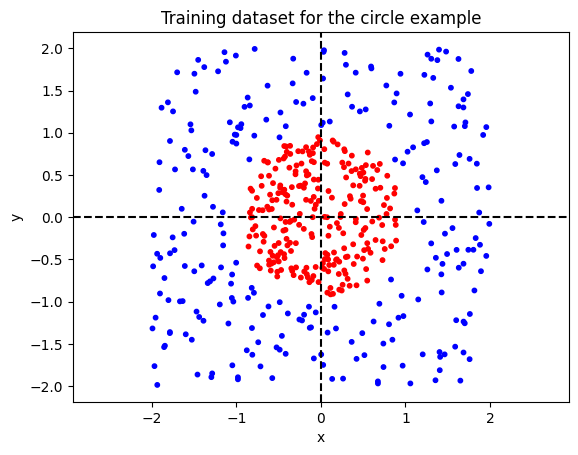

In [6]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr_r", s=10)
plt.axvline(0.0, color="k", linestyle="--")
plt.axhline(0.0, color="k", linestyle="--")
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")
plt.title("Training dataset for the circle example")
plt.show()

In [7]:
print(len(y_train))

500


In [8]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32).float()
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).float()  # add dimension if needed

X_val_standardized = torch.tensor(X_val_standardized, dtype=torch.float32).float()
y_val = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_standardized, y_train)
val_ds = TensorDataset(X_val_standardized, y_val)

train_dataloader = DataLoader(train_ds, batch_size=64)
val_dataloader = DataLoader(val_ds, batch_size=64)

In [9]:
M = 10
seeds = [46]
# seeds = [11]

radii = np.linspace(0.2, 1.8, 40)
loss_fn = nn.SmoothL1Loss()

In [10]:
def point_generator(radius, n=32):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

In [11]:
T = 1.0
all_LEs = []
all_LEs_min = []
for seed in seeds:
    torch.manual_seed(seed)

    neural_ode = NeuralODEClassifier(input_dim=2, hidden_dim=3)
    # neural_ode.apply(lambda m: init_weights(m, init_type="gaussian", gain=0.9))

    train(neural_ode, train_dataloader, val_dataloader, loss_fn, acc_target=1.01, seed=seed, epochs=1000)

    # run_LEs = []
    # run_LEs_min = []

    # neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

#     for r in radii:
#         X = point_generator(r, n=32)
#         X = torch.tensor(X, dtype=torch.float32)

#         le_r, le_rmin = lyapunov_autograd(X[0, :], X[1, :], neural_ode_trunc, mean, std, T=T)

#         run_LEs.append(le_r.mean())
#         run_LEs_min.append(le_rmin.mean())

#     all_LEs.append(run_LEs)
#     all_LEs_min.append(run_LEs_min)

# all_LEs = np.array(all_LEs)
# all_LEs_min = np.array(all_LEs_min) 

Epoch 0 | Train Loss 0.588021 | Validation Accuracy 0.132000
Epoch 20 | Train Loss 0.254694 | Validation Accuracy 0.296000
Epoch 40 | Train Loss 0.060579 | Validation Accuracy 0.860000
Epoch 60 | Train Loss 0.043732 | Validation Accuracy 0.912000
Epoch 80 | Train Loss 0.034993 | Validation Accuracy 0.936000
Epoch 100 | Train Loss 0.027632 | Validation Accuracy 0.960000
Epoch 120 | Train Loss 0.020173 | Validation Accuracy 0.968000
Epoch 140 | Train Loss 0.013156 | Validation Accuracy 0.984000
Epoch 160 | Train Loss 0.009581 | Validation Accuracy 0.984000
Epoch 180 | Train Loss 0.006346 | Validation Accuracy 0.984000
Epoch 200 | Train Loss 0.004745 | Validation Accuracy 0.988000
Epoch 220 | Train Loss 0.003806 | Validation Accuracy 0.992000
Epoch 240 | Train Loss 0.002940 | Validation Accuracy 0.992000
Epoch 260 | Train Loss 0.002215 | Validation Accuracy 0.996000
Epoch 280 | Train Loss 0.001823 | Validation Accuracy 0.996000
Epoch 300 | Train Loss 0.001438 | Validation Accuracy 0.99600

In [12]:
x_vals = np.linspace(-2, 2, 50)  # Make it 50 to improve time it takes
y_vals = np.linspace(-2, 2, 50)

t0 = 0.0
# t1_list = np.linspace(0.01, 1.0, 20)
t1 = 1.0

In [13]:
theta = np.linspace(0, 2*np.pi, 50, endpoint=False)

ring_offsets = np.array([
    -0.40,
    -0.30,
    -0.20,
    # -0.15,
    -0.10,
    # -0.05,
    # -0.02,
     0.00,
    #  0.02,
     0.05,
     0.10,
    #  0.15,
     0.20,
     0.30,
     0.40,
])

rings = []

for eps in ring_offsets:

    r = 1.0 + eps

    ring = np.stack(
        [
            r * np.cos(theta),
            r * np.sin(theta)
        ],
        axis=1
    )

    rings.append(ring)

all_points = np.concatenate(rings, axis=0)

In [27]:
# lyap_grid_list = []
# lyap_grid_min_list = []
# for t1 in t1_list:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))
lyap_grid_mid = np.zeros_like(lyap_grid)
lyap_grid_min = np.zeros_like(lyap_grid)

max_dirs = np.zeros((len(y_vals), len(x_vals), 3))
mid_dirs = np.zeros((len(y_vals), len(x_vals), 3))
min_dirs = np.zeros((len(y_vals), len(x_vals), 3))

plane_points = np.zeros((len(y_vals), len(x_vals), 3))

neural_ode_trunc = NeuralODE_Full(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        x0_2d = torch.tensor([[x, y]], dtype=torch.float32)

        x0_2d = ((x0_2d - mean) / std).float()

        x0 = torch.cat(
            [x0_2d, torch.zeros(1, 1)],
            dim=1
        )

        plane_points[j, i] = x0[0].detach().cpu().numpy()

        # Compute Jacobian
        J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)

        # Singular values
        U, svals, Vh = torch.linalg.svd(J)

        # Largest Lyapunov proxy
        lyap_grid[j, i] = (1.0/(t1-t0)) * torch.log(svals[0]).item()
        lyap_grid_mid[j, i] = (1.0/(t1-t0)) * torch.log(svals[1]).item()
        lyap_grid_min[j, i] =(1.0/(t1-t0)) * torch.log(svals[2]).item()

        # Right singular vectors
        V = Vh.t()

        max_dirs[j, i] = V[:, 0].detach().cpu().numpy()
        mid_dirs[j, i] = V[:, 1].detach().cpu().numpy()
        min_dirs[j, i] = V[:, 2].detach().cpu().numpy()

    # lyap_grid_list.append(lyap_grid)
    # lyap_grid_min_list.append(lyap_grid_min)

In [15]:
N = len(all_points)

largest_ftle = np.zeros(N)
middle_ftle  = np.zeros(N)
smallest_ftle = np.zeros(N)

max_dirs = np.zeros((N, 3))
mid_dirs = np.zeros((N, 3))
min_dirs = np.zeros((N, 3))

plane_points = np.zeros((N, 3))

neural_ode_trunc = NeuralODE_Full(neural_ode_model=neural_ode)
nn_lyap = NN_LyapExp(neural_ode_trunc)

for k, (x, y) in enumerate(all_points):

    x0_2d = torch.tensor(
        [[x, y]],
        dtype=torch.float32
    )

    x0_2d = ((x0_2d - mean) / std).float()

    x0 = torch.cat(
        [x0_2d, torch.zeros(1, 1)],
        dim=1
    )

    plane_points[k] = x0[0].detach().cpu().numpy()

    J = nn_lyap.jacobian_flow(
        x0,
        t0=t0,
        t1=t1
    )

    U, svals, Vh = torch.linalg.svd(J)

    largest_ftle[k] = (
        torch.log(svals[0])/(t1-t0)
    ).item()

    middle_ftle[k] = (
        torch.log(svals[1])/(t1-t0)
    ).item()

    smallest_ftle[k] = (
        torch.log(svals[2])/(t1-t0)
    ).item()

    V = Vh.T

    max_dirs[k] = V[:,0].detach().cpu().numpy()
    mid_dirs[k] = V[:,1].detach().cpu().numpy()
    min_dirs[k] = V[:,2].detach().cpu().numpy()

In [16]:
lyap_grid_2c = np.zeros(N)
lyap_grid_min_2c = np.zeros_like(lyap_grid_2c)

max_dirs_2c = np.zeros((N, 2))
min_dirs_2c = np.zeros((N, 2))

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for k, (x, y) in enumerate(all_points):

    x0_2d = torch.tensor(
        [[x, y]],
        dtype=torch.float32
    )

    x0_2d = ((x0_2d - mean) / std).float()

    x0 = x0_2d

    J = nn_lyap.jacobian_flow(
        x0,
        t0=t0,
        t1=t1
    )

    U, svals, Vh = torch.linalg.svd(J)

    lyap_grid_2c[k] = (
        torch.log(svals[0])/(t1-t0)
    ).item()

    lyap_grid_min_2c[k] = (
        torch.log(svals[1])/(t1-t0)
    ).item()

    V = Vh.T

    max_dirs_2c[k] = V[:,0].detach().cpu().numpy()
    min_dirs_2c[k] = V[:,1].detach().cpu().numpy()

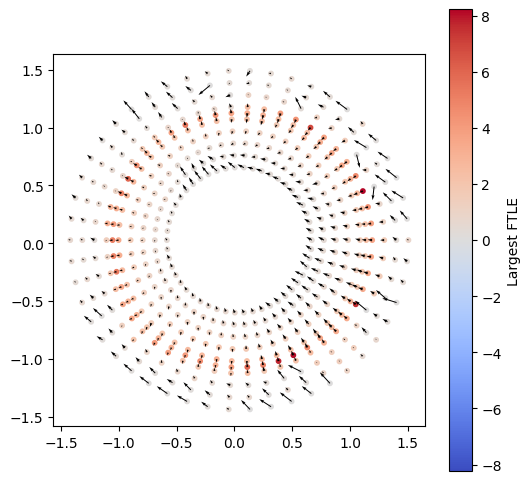

In [17]:
proj = max_dirs[..., :2]   # keep x,y components only

norm = np.linalg.norm(proj, axis=-1, keepdims=True)
proj_unit = proj / (norm + 1e-12)

fig, ax = plt.subplots(figsize=(6,6))

vmax = np.max(np.abs(largest_ftle))

sc = ax.scatter(
    plane_points[:,0],
    plane_points[:,1],
    c=largest_ftle,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax,
    s=10
)

skip = 1

idx = np.arange(0, len(plane_points), skip)

ax.quiver(
    plane_points[idx,0],
    plane_points[idx,1],
    proj[idx,0],
    proj[idx,1],
    color="black",
    scale=25
)

plt.colorbar(sc, ax=ax, label="Largest FTLE")
ax.set_aspect("equal")
plt.show()

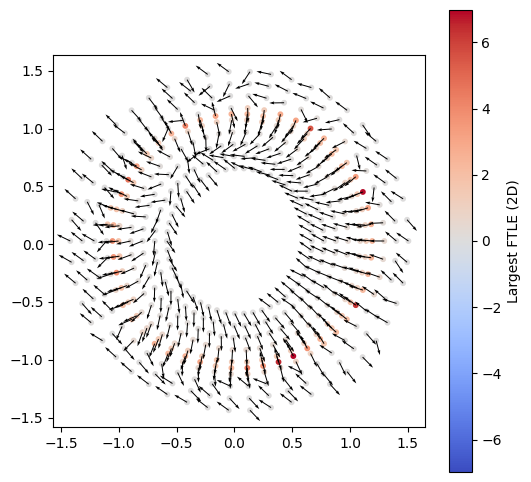

In [18]:
fig, ax = plt.subplots(figsize=(6,6))

vmax = np.max(np.abs(lyap_grid_2c))

sc = ax.scatter(
    plane_points[:,0],
    plane_points[:,1],
    c=lyap_grid_2c,
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax,
    s=10
)

skip = 1

idx = np.arange(0, len(plane_points), skip)

ax.quiver(
    plane_points[idx,0],
    plane_points[idx,1],
    max_dirs_2c[idx,0],
    max_dirs_2c[idx,1],
    color="black",
    scale=25
)

plt.colorbar(sc, ax=ax, label="Largest FTLE (2D)")
ax.set_aspect("equal")
plt.show()

In [19]:
proj = max_dirs[:, :2]

proj_norm = np.linalg.norm(proj, axis=1, keepdims=True)
proj_hat = proj / (proj_norm + 1e-12)

v2_norm = np.linalg.norm(max_dirs_2c, axis=1, keepdims=True)
v2_hat = max_dirs_2c / (v2_norm + 1e-12)

alignment = np.abs(
    np.sum(proj_hat * v2_hat, axis=1)
)

In [20]:
print(alignment.shape)
print(alignment[:10])
print(np.unique(np.round(alignment, 6)))

(500,)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1.]


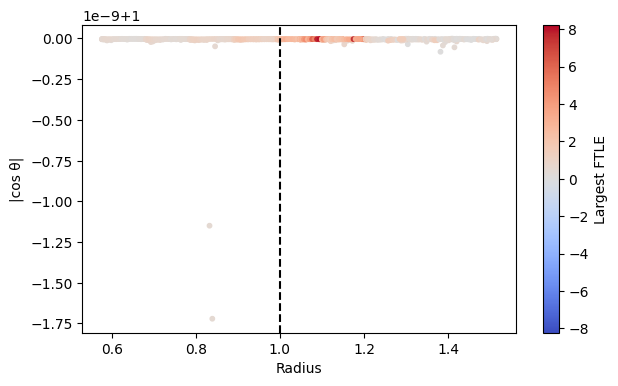

In [21]:
radius = np.linalg.norm(
    plane_points[:, :2],
    axis=1
)

plt.figure(figsize=(7,4))

plt.scatter(
    radius,
    alignment,
    c=largest_ftle,
    cmap="coolwarm",
    vmin=-np.max(np.abs(largest_ftle)),
    vmax=np.max(np.abs(largest_ftle)),
    s=10
)

plt.axvline(1.0, color='black', linestyle='--')

plt.xlabel("Radius")
plt.ylabel("|cos θ|")

plt.colorbar(label="Largest FTLE")

plt.show()

In [22]:
def plot_radial_alignment(plane_points, dirs, ftle, m, title):

    proj = dirs[:, :2]

    proj_norm = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_hat = proj / (proj_norm + 1e-12)

    xy = plane_points[:, :2]

    r_norm = np.linalg.norm(xy, axis=1, keepdims=True)
    r_hat = xy / (r_norm + 1e-12)

    radial_alignment = np.abs(
        np.sum(proj_hat * r_hat, axis=1)
    )

    radius = np.linalg.norm(xy, axis=1)

    plt.figure(figsize=(7,4))

    plt.scatter(
        radius,
        radial_alignment,
        c=ftle,
        cmap="coolwarm",
        vmin=-m,
        vmax=m,
        s=10
    )

    plt.axvline(1.0, color="black", linestyle="--")

    plt.xlabel("Radius")
    plt.ylabel("Radial alignment")
    plt.title(title)

    plt.colorbar(label="FTLE")
    plt.show()

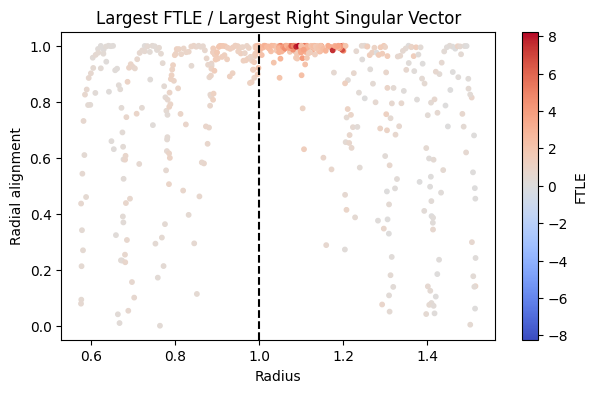

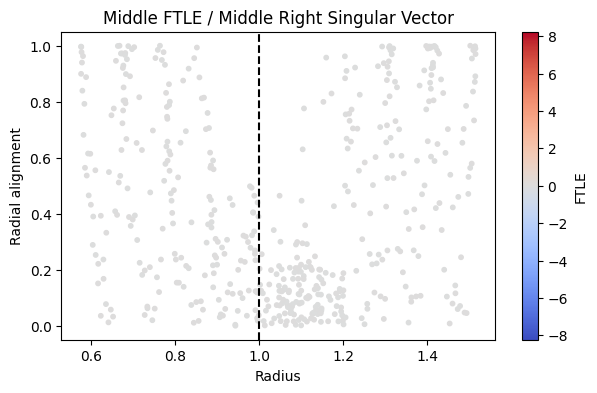

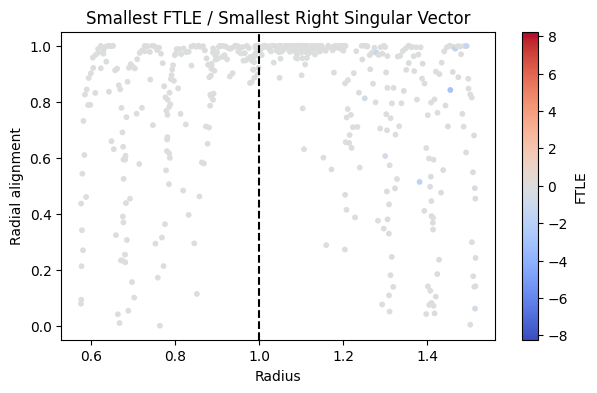

In [23]:
m = max(
    np.max(np.abs(largest_ftle)),
    np.max(np.abs(middle_ftle)),
    np.max(np.abs(smallest_ftle))
)

plot_radial_alignment(
    plane_points,
    max_dirs,
    largest_ftle,
    m,
    "Largest FTLE / Largest Right Singular Vector"
)

plot_radial_alignment(
    plane_points,
    mid_dirs,
    middle_ftle,
    m,
    "Middle FTLE / Middle Right Singular Vector"
)

plot_radial_alignment(
    plane_points,
    min_dirs,
    smallest_ftle,
    m,
    "Smallest FTLE / Smallest Right Singular Vector"
)

In [ ]:
import plotly.graph_objects as go

X3 = plane_points[:, :, 0]
Y3 = plane_points[:, :, 1]
Z3 = plane_points[:, :, 2]

fig = go.Figure()

m = np.max(np.abs(lyap_grid))

fig.add_trace(
    go.Scatter3d(
        x=plane_points[:,0],
        y=plane_points[:,1],
        z=plane_points[:,2],
        mode='markers',
        marker=dict(
            size=3,
            color=largest_ftle,
            colorscale='RdBu_r',
            cmin=-m,
            cmax=m,
            colorbar = dict(title='Largest FTLE')
        )
    )
)

# fig.add_trace(
#     go.Scatter3d(
#         x=X3.ravel(),
#         y=Y3.ravel(),
#         z=Z3.ravel(),
#         mode='markers',
#         marker=dict(
#             size=3,
#             color=lyap_grid.ravel(),
#             colorscale='RdBu_r',
#             cmin=-m,
#             cmax=m,
#             colorbar=dict(title='Largest FTLE')
#         )
#     )
# )

# skip = 5

# for i in range(0, X3.shape[1], skip):
#     for j in range(0, X3.shape[0], skip):

#         x0 = X3[j,i]
#         y0 = Y3[j,i]
#         z0 = Z3[j,i]

#         v = max_dirs[j,i]

#         scale = 0.15

#         fig.add_trace(
#             go.Scatter3d(
#                 x=[x0, x0 + scale*v[0]],
#                 y=[y0, y0 + scale*v[1]],
#                 z=[z0, z0 + scale*v[2]],
#                 mode='lines',
#                 line=dict(color='black', width=4),
#                 showlegend=False
#             )
#         )

#         v = mid_dirs[j,i]

#         scale = 0.15

#         fig.add_trace(
#             go.Scatter3d(
#                 x=[x0, x0 + scale*v[0]],
#                 y=[y0, y0 + scale*v[1]],
#                 z=[z0, z0 + scale*v[2]],
#                 mode='lines',
#                 line=dict(color='green', width=4),
#                 showlegend=False
#             )
#         )

#         v = min_dirs[j,i]

#         scale = 0.15

#         fig.add_trace(
#             go.Scatter3d(
#                 x=[x0, x0 + scale*v[0]],
#                 y=[y0, y0 + scale*v[1]],
#                 z=[z0, z0 + scale*v[2]],
#                 mode='lines',
#                 line=dict(color='red', width=4),
#                 showlegend=False
#             )
#         )

skip = 0

for k in range(0, len(plane_points)):

    x0, y0 = plane_points[k]

    scale = 0.15

    # largest
    v = max_dirs[k]

    fig.add_trace(
        go.Scatter3d(
            x=[x0, x0 + scale*v[0]],
            y=[y0, y0 + scale*v[1]],
            z=[z0, z0 + scale*v[2]],
            mode='lines',
            line=dict(color='black', width=4),
            showlegend=False
        )
    )

    # # middle
    # v = mid_dirs[k]

    # fig.add_trace(
    #     go.Scatter3d(
    #         x=[x0, x0 + scale*v[0]],
    #         y=[y0, y0 + scale*v[1]],
    #         z=[z0, z0 + scale*v[2]],
    #         mode='lines',
    #         line=dict(color='green', width=4),
    #         showlegend=False
    #     )
    # )

    # # smallest
    # v = min_dirs[k]

    # fig.add_trace(
    #     go.Scatter3d(
    #         x=[x0, x0 + scale*v[0]],
    #         y=[y0, y0 + scale*v[1]],
    #         z=[z0, z0 + scale*v[2]],
    #         mode='lines',
    #         line=dict(color='red', width=4),
    #         showlegend=False
    #     )
    # )

fig.update_layout(
    scene=dict(
        aspectmode='data'
    )
)

fig.show()

fig.write_html(
    save_dir / "orthogonal_3ds_1ftle_46:ring.html",
    include_plotlyjs="cdn"
)

ValueError: too many values to unpack (expected 2)

In [34]:
X3 = plane_points[:, :, 0]
Y3 = plane_points[:, :, 1]
Z3 = plane_points[:, :, 2]

m = np.max(np.abs(lyap_grid))

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=X3.ravel(),
        y=Y3.ravel(),
        z=Z3.ravel(),
        mode='markers',
        marker=dict(
            size=3,
            color=lyap_grid.ravel(),
            colorscale='RdBu_r',
            cmin=-m,
            cmax=m,
            colorbar=dict(title='Largest FTLE')
        )
    )
)

skip = 4

for i in range(0, X3.shape[1], skip):
    for j in range(0, X3.shape[0], skip):

        x0 = X3[j,i]
        y0 = Y3[j,i]
        z0 = Z3[j,i]

        v = max_dirs[j,i]

        scale = 0.05
        fig.add_trace(
            go.Scatter3d(
                x=[x0, x0 + scale*v[0]],
                y=[y0, y0 + scale*v[1]],
                z=[z0, z0 + scale*v[2]],
                mode='lines',
                line=dict(color='black', width=4),
                showlegend=False
            )
        )

fig.update_layout(
    scene=dict(
        aspectmode='data'
    )
)

fig.show()

fig.write_html(
    save_dir / "orthogonal_3ds_1ftle_46.html",
    include_plotlyjs="cdn"
)

In [25]:
fig = go.Figure()

m = np.max(np.abs(lyap_grid_mid))

fig.add_trace(
    go.Scatter3d(
        x=X3.ravel(),
        y=Y3.ravel(),
        z=Z3.ravel(),
        mode='markers',
        marker=dict(
            size=3,
            color=lyap_grid_mid.ravel(),
            colorscale='RdBu_r',
            cmin=-m,
            cmax=m,
            colorbar=dict(title='Middle FTLE')
        )
    )
)

skip = 5

for i in range(0, X3.shape[1], skip):
    for j in range(0, X3.shape[0], skip):

        x0 = X3[j,i]
        y0 = Y3[j,i]
        z0 = Z3[j,i]

        v = mid_dirs[j,i]

        scale = 0.05
        fig.add_trace(
            go.Scatter3d(
                x=[x0, x0 + scale*v[0]],
                y=[y0, y0 + scale*v[1]],
                z=[z0, z0 + scale*v[2]],
                mode='lines',
                line=dict(color='green', width=4),
                showlegend=False
            )
        )

# fig.update_layout(
#     scene=dict(
#         aspectmode='data'
#     )
# )

fig.show()

fig.write_html(
    save_dir / "orthogonal_3ds_2ftle_46.html",
    include_plotlyjs="cdn"
)

NameError: name 'X3' is not defined

In [ ]:
fig = go.Figure()

m = np.max(np.abs(lyap_grid_min))


fig.add_trace(
    go.Scatter3d(
        x=X3.ravel(),
        y=Y3.ravel(),
        z=Z3.ravel(),
        mode='markers',
        marker=dict(
            size=3,
            color=lyap_grid_min.ravel(),
            colorscale='RdBu_r',
            cmin=-m,
            cmax=m,
            colorbar=dict(title='Smallest FTLE')
        )
    )
)

skip = 4

for i in range(0, X3.shape[1], skip):
    for j in range(0, X3.shape[0], skip):

        x0 = X3[j,i]
        y0 = Y3[j,i]
        z0 = Z3[j,i]

        v = min_dirs[j,i]

        scale = 0.15

        fig.add_trace(
            go.Scatter3d(
                x=[x0, x0 + scale*v[0]],
                y=[y0, y0 + scale*v[1]],
                z=[z0, z0 + scale*v[2]],
                mode='lines',
                line=dict(color='red', width=4),
                showlegend=False
            )
        )

fig.update_layout(
    scene=dict(
        aspectmode='data'
    )
)

fig.show()

fig.write_html(
    save_dir / "orthogonal_3ds_3ftle_46.html",
    include_plotlyjs="cdn"
)

In [ ]:
# lyap_grid_list = []
# lyap_grid_min_list = []
# for t1 in t1_list:
lyap_grid_2d = np.zeros((len(x_vals), len(y_vals)))
lyap_grid_min_2d = np.zeros_like(lyap_grid_2d)

max_dirs_2d = np.zeros((len(y_vals), len(x_vals), 2))
min_dirs_2d = np.zeros((len(y_vals), len(x_vals), 2))

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)

        # Singular values
        U, svals, Vh = torch.linalg.svd(J)

        # Largest Lyapunov proxy
        lyap_grid_2d[j, i] = (1.0/(t1-t0)) * torch.log(svals.max()).item()
        lyap_grid_min_2d[j, i] =(1.0/(t1-t0)) * torch.log(svals.min()).item()

        # Right singular vectors
        V = Vh.t()

        # Largest stretching direction  
        max_dirs_2d[j, i] = V[:, 0].detach().cpu().numpy()

        # Smallest stretching direction
        min_dirs_2d[j, i] = V[:, 1].detach().cpu().numpy()

    # lyap_grid_list.append(lyap_grid)
    # lyap_grid_min_list.append(lyap_grid_min)

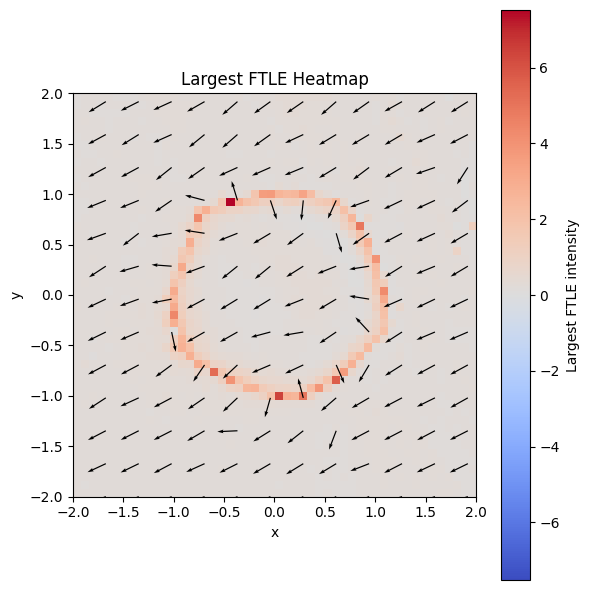

In [ ]:
X, Y = np.meshgrid(x_vals, y_vals)

fig, ax = plt.subplots(figsize=(6,6))

v_max = np.max(np.abs(lyap_grid_2d))
v_min = np.max(np.abs(lyap_grid_min_2d))
v = max(v_max, v_min)

im = ax.imshow(
    lyap_grid_2d,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v,
    vmax=v
)

skip = 4

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],

    max_dirs_2d[::skip, ::skip, 0],
    max_dirs_2d[::skip, ::skip, 1],

    color='black',
    scale=20,
    width=0.003
)

fig.colorbar(im, ax=ax, label="Largest FTLE intensity")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Largest FTLE Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "orthogonal_2d_1ftle_46", dpi=300, bbox_inches='tight')

plt.show()

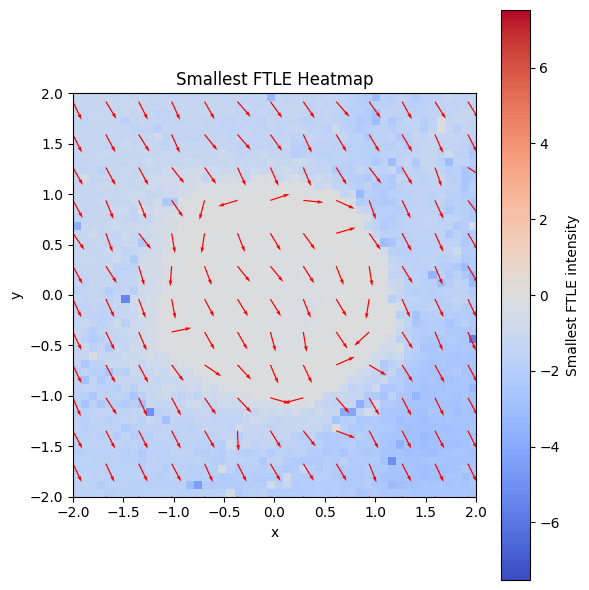

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))


im = ax.imshow(
    lyap_grid_min,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v,
    vmax=v
)

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],

    min_dirs_2d[::skip, ::skip, 0],
    min_dirs_2d[::skip, ::skip, 1],

    color='red',
    scale=20,
    width=0.003
)

fig.colorbar(im, ax=ax, label="Smallest FTLE intensity")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Smallest FTLE Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "orthogonal_2d_2ftle_46.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
points = np.stack([X.ravel(), Y.ravel()], axis=1)
points_t = torch.tensor(points, dtype=torch.float32)

points_t = ((points_t - mean) / std).float()

neural_ode.eval()
with torch.no_grad():
    preds = neural_ode(points_t).cpu().numpy()

Z = preds.reshape(len(x_vals), len(y_vals))

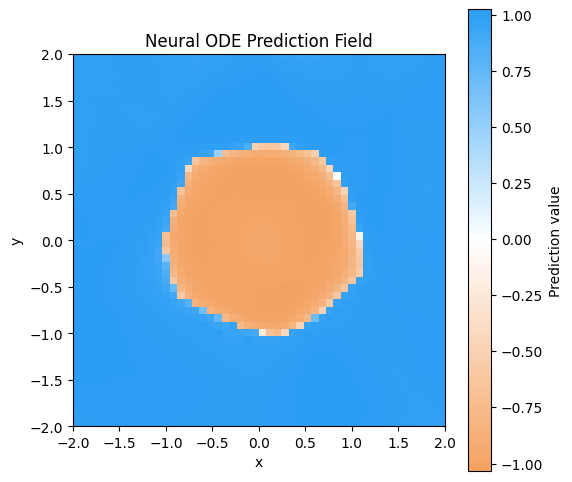

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    Z,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap=tf_playground,
)

fig.colorbar(im, ax=ax, label="Prediction value")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Neural ODE Prediction Field")


fig.savefig(save_dir / "orthogonalb_td_dopri_pred_46.png", dpi=300)

plt.show()

In [ ]:
Y_true = np.where(X**2 + Y**2 < 1, -1, 1)

Z = preds.reshape(len(y_vals), len(x_vals))
Y_pred = np.where(Z < 0, -1, 1)

accuracy = (Y_pred.flatten() == Y_true.flatten()).mean()
print("Accuracy:", accuracy)

Accuracy: 0.9728


In [ ]:
t_eval = torch.linspace(0, 1, 100)

with torch.no_grad():
    traj = neural_ode.get_hidden_trajectory(points_t, t_eval) # Shape time_steps, num_points, 3

In [ ]:
x_colors = points_t[:, 0]
y_colors = points_t[:, 1]

labels = torch.where((x_colors**2 + y_colors**2)<=1, -1, 1)

colors = torch.zeros((points_t.shape[0], 3)) # RGB

# Red if the point is inside the circle
colors[labels == -1] = torch.tensor([1.0, 0.0, 0.0])

# Blue if the point is outside the circle
colors[labels == 1] = torch.tensor([0.0, 0.0, 1.0])
colors_np = colors.numpy()

Saved GIF: xavier_normal_hidden_flow_42.gif


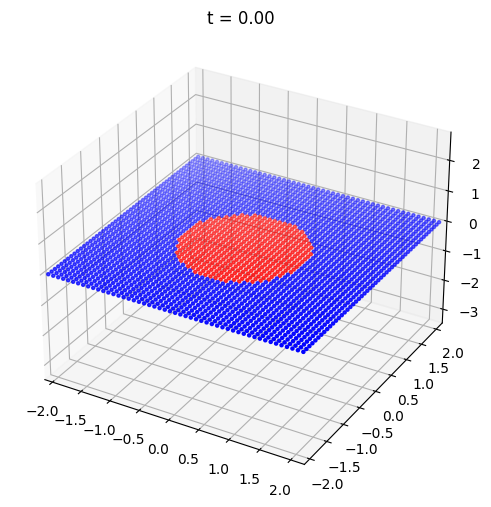

In [ ]:
from matplotlib.animation import FuncAnimation
# matplotlib.use("Agg")

T, N, _ = traj.shape
traj_np = traj.cpu().numpy()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Initial scatter
scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_np, s=5)

ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
# ax.set_title("Neural ODE flow in hidden space"

def update(frame):
    scatter._offsets3d = (
        traj_np[frame,:,0],
        traj_np[frame,:,1],
        traj_np[frame,:,2],
    )
    ax.set_title(f"t = {1*frame/(T-1):.2f}")
    return scatter,

anim = FuncAnimation(fig, update, frames=T, interval=80)

anim.save(f"{save_dir}/orthogonal_hidden_flow_46.gif", writer="pillow", fps=15)
print("Saved GIF: xavier_normal_hidden_flow_42.gif")

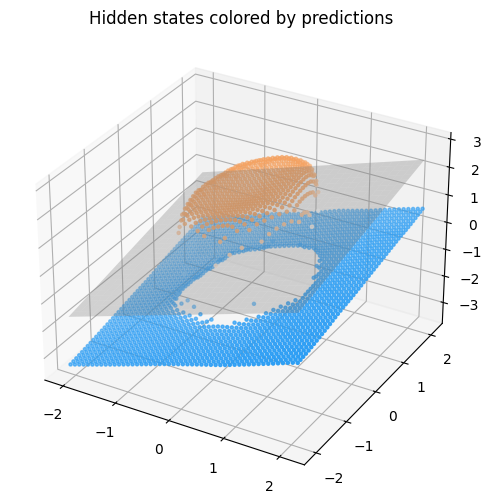

In [ ]:
# Z is shape (len(x_vals), len(y_vals)), e.g., (100,100)
Z_flat = Z.ravel()  # shape (10000,)

# Normalize predictions to [0,1] if needed
Z_norm = (Z_flat + 1) / 2  # assuming predictions in [-1,1]

# Map to colors
colors_pred = tf_playground(Z_norm)  # shape (10000, 4) 
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_pred, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()


In [ ]:
fig.savefig(f"{save_dir}/orthogonal_final_frame_pred_46.png")

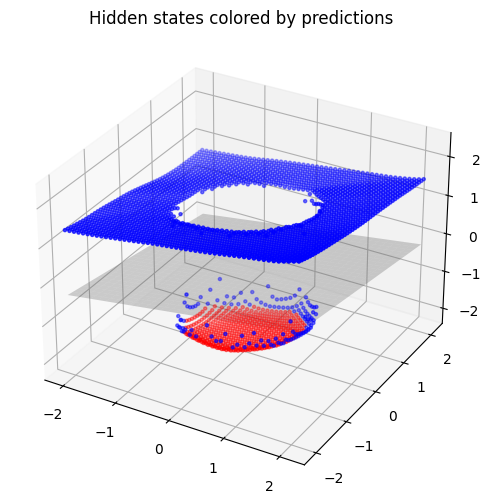

In [ ]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_np, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()

In [ ]:
fig.savefig(f"{save_dir}/orthogonal_final_frame_true_46.png")

In [ ]:
print(traj.std(dim=1))

tensor([[1.2311, 1.2348, 0.0000],
        [1.2311, 1.2348, 0.0050],
        [1.2311, 1.2348, 0.0103],
        [1.2311, 1.2348, 0.0158],
        [1.2311, 1.2348, 0.0215],
        [1.2311, 1.2348, 0.0276],
        [1.2311, 1.2348, 0.0339],
        [1.2311, 1.2348, 0.0405],
        [1.2311, 1.2348, 0.0473],
        [1.2311, 1.2348, 0.0545],
        [1.2311, 1.2348, 0.0618],
        [1.2311, 1.2348, 0.0695],
        [1.2311, 1.2348, 0.0774],
        [1.2311, 1.2348, 0.0855],
        [1.2311, 1.2348, 0.0939],
        [1.2311, 1.2348, 0.1025],
        [1.2311, 1.2348, 0.1114],
        [1.2311, 1.2348, 0.1204],
        [1.2311, 1.2348, 0.1298],
        [1.2311, 1.2348, 0.1393],
        [1.2311, 1.2348, 0.1491],
        [1.2311, 1.2348, 0.1591],
        [1.2311, 1.2348, 0.1693],
        [1.2311, 1.2348, 0.1797],
        [1.2311, 1.2348, 0.1904],
        [1.2311, 1.2348, 0.2011],
        [1.2311, 1.2348, 0.2121],
        [1.2311, 1.2348, 0.2232],
        [1.2311, 1.2348, 0.2346],
        [1.231